In [3]:
import numpy as np
from typing import Dict, Any
from tqdm import tqdm

from model_ranking.correlation import calculate_correlation_statistics
from model_ranking.feature_ranking import get_precomputed_feature_path
from model_ranking.GBC import bhattacharyya_coefficient
from model_ranking.plots import plot_performance_vs_gbc
from model_ranking.results import (
    get_NA_performance_score,
    transfer_results_to_arrays,
)
from model_ranking.utils import load_npz

INFO: P [MainThread] 2025-08-08 15:17:14,820 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


In [4]:
Unet_models = ["E_model5", "Hm_model4", "Rm_model4", "V_model2"]
Unet_models_NA = ["E_model_NA2", "Hm_model_NA2", "Rm_model_NA2", "V_model_NA2"]
Unetr_models = ["E_model_Unetr2", "Hm_model_Unetr2", "Rm_model_Unetr2"]
ResUnet_models = ["E_model_Res1", "Hm_model_Res1", "Rm_model_Res1", "V_model_Res1"]

In [5]:
targets = ["EPFL", "Hmito", "Rmito", "VNC"]
source_models = Unet_models + Unet_models_NA + Unetr_models + ResUnet_models
feature_base_path = "/scratch/talks/sampled_features/semantic_segmentation/mitochondria"
performance_base_path = "/scratch/talks/consistency_results/patch_segmentation/mitochondria"
save_keys = {
    "NA": "decoders.2",
    "Unetr": "decoder2",
    "Res": "decoders.3",
}

Processing target: EPFL


100%|██████████| 15/15 [00:15<00:00,  1.06s/it]


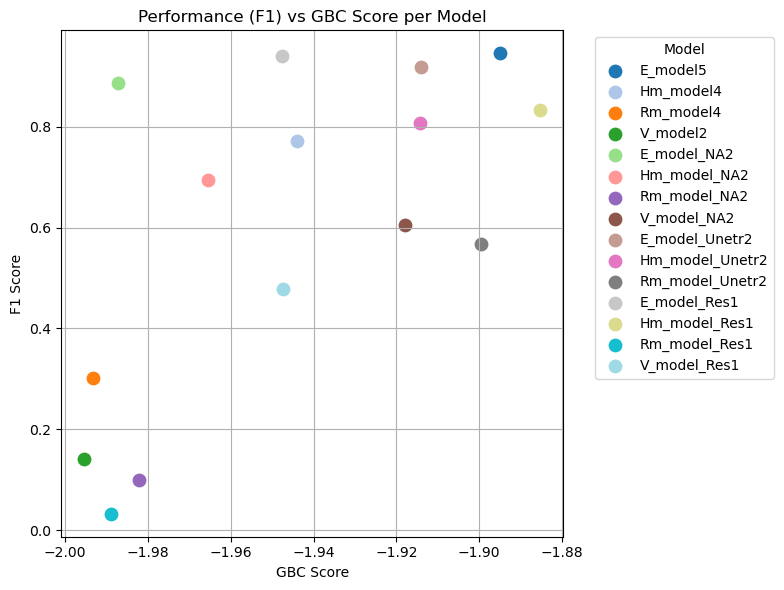

Processing target: Hmito


100%|██████████| 15/15 [00:42<00:00,  2.82s/it]


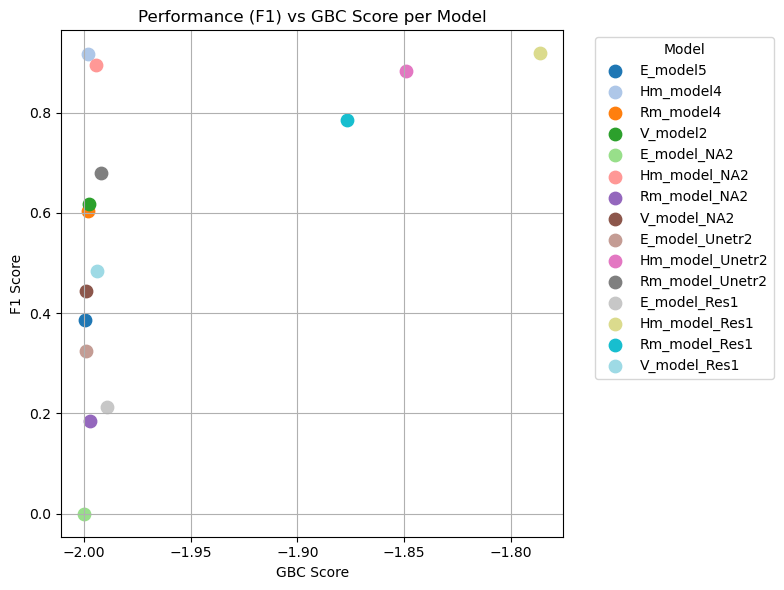

Processing target: Rmito


100%|██████████| 15/15 [00:44<00:00,  2.96s/it]


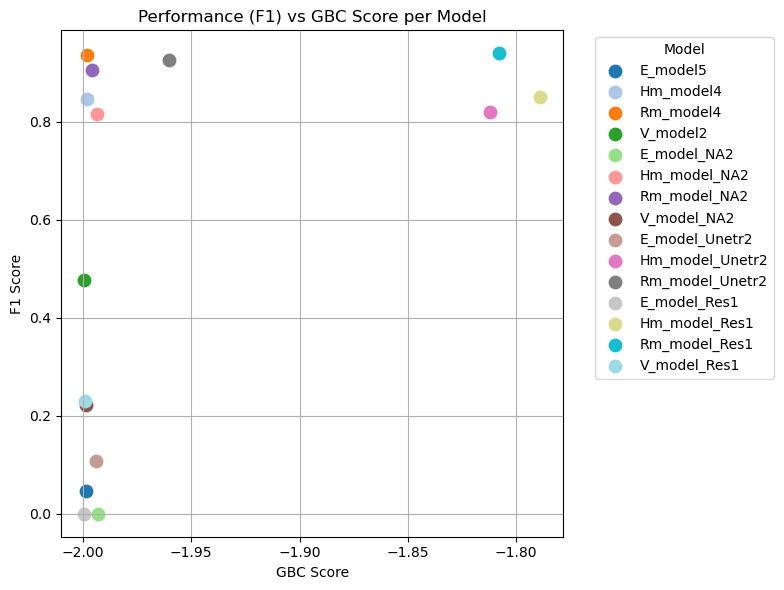

Processing target: VNC


100%|██████████| 15/15 [00:10<00:00,  1.49it/s]


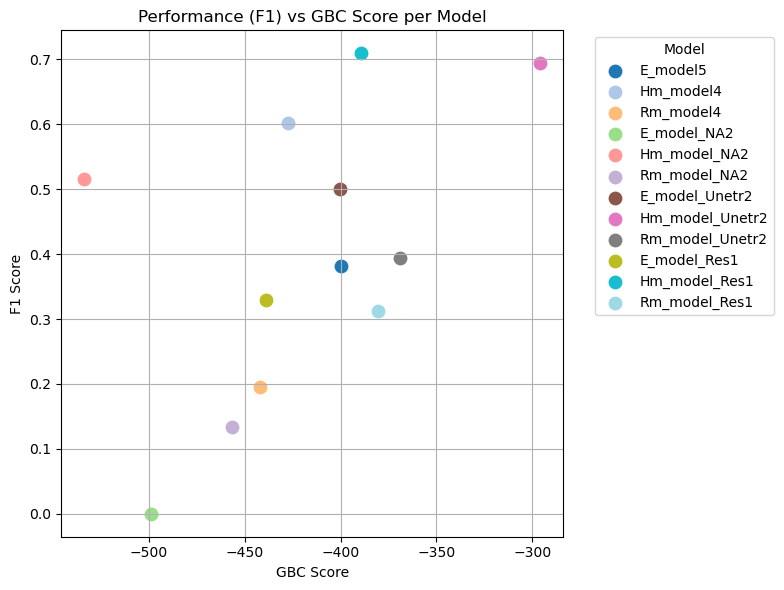

In [6]:
gbc_per_target: Dict[str, Dict[str, float]] = {}
performance_per_target: Dict[str, Dict[str, float]] = {}
feature_ids = list(save_keys.keys())
for target in targets:
    print(f"Processing target: {target}")
    performance_per_model: Dict[str, Any] = {}
    gbc_per_model: Dict[str, float] = {}
    for model in tqdm(source_models):
        if ("V" in model) and (target == "VNC"):
            continue
        else:
            model_identifier = model.split('_')[-1][:-1]
            if model_identifier in feature_ids:
                key = save_keys[model_identifier]
            else:
                key = "decoders.2"

            feature_path = get_precomputed_feature_path(model, target, feature_base_path)
            features = load_npz(feature_path, f"{key}_features")
            labels = load_npz(feature_path, f"{key}_labels")

            performance_score = get_NA_performance_score(model, target, performance_base_path)
            performance_per_model[model] = np.median(performance_score[:, 1])

            non_zero_patch_ids = np.where(~np.all(labels == 0, axis=1))[0]
            features = features[non_zero_patch_ids]
            labels = labels[non_zero_patch_ids]

            features_flat = features.reshape(-1, features.shape[-1])
            labels_flat = labels.reshape(-1)

            gbc = bhattacharyya_coefficient(features_flat, labels_flat)
            gbc_per_model[model] = gbc

    gbc_per_target[target] = gbc_per_model
    performance_per_target[target] = performance_per_model
    plot_performance_vs_gbc(performance_per_model, gbc_per_model)

In [7]:
per_target_KT = np.zeros((len(targets), 1, 2))
per_target_SP = np.zeros((len(targets), 1, 2))
per_target_PE = np.zeros((len(targets), 1, 2))
for i, target in enumerate(targets):
    gbc_scores, NA_perf_scores = transfer_results_to_arrays(
        gbc_per_target[target],
        performance_per_target[target],
    )

    (per_target_KT[i], 
        per_target_SP[i], 
        per_target_PE[i]
    ) = calculate_correlation_statistics(
            gbc_scores,
            NA_perf_scores,
        )

In [8]:
import pandas as pd
idx = 0
df = pd.DataFrame(
    {
        "kt": per_target_KT[:, idx, 0], 
        "kt pval": per_target_KT[:, idx, 1], 
        "s rho": per_target_SP[:, idx, 0], 
        "s rho pval": per_target_SP[:, idx, 1], 
        "pr": per_target_PE[:, idx, 0], 
        "pr pval": per_target_PE[:, idx, 1]
    },
)
df["targets"] = targets
df = df.set_index("targets")
df.index = pd.MultiIndex.from_product([["Mito"], df.index], names=["Task", "targets"])
# Round all float columns to 2 significant figures
df = df.map(lambda x: round(x, 2) if isinstance(x, float) else x)
print(df)

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.65     0.01   0.60        0.02  0.45     0.02
     Hmito    0.54     0.04   0.54        0.03  0.43     0.03
     Rmito    0.47     0.08   0.51        0.07  0.34     0.09
     VNC      0.51     0.09   0.48        0.12  0.39     0.09
